# data
source: https://www.gob.mx/salud/documentos/datos-abiertos-bases-historicas-direccion-general-de-epidemiologia

https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/

https://www.inegi.org.mx/app/ageeml/

In [2]:
%pip install geopandas
%pip install pyogrio
%pip install shapely

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

path = r"C:\Users\Tosin\Downloads\BMC\dengue.csv"
df = pd.read_csv(path, low_memory=False)

print(df.shape)
print(df.columns.tolist())
print(df["FECHA_SIGN_SINTOMAS"].min(), df["FECHA_SIGN_SINTOMAS"].max())
print((df["ESTATUS_CASO"] == 1).sum())
print(df[["ENTIDAD_RES", "MUNICIPIO_RES"]].drop_duplicates().shape[0])


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Tosin\Anaconda3\Conda\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Tosin\Anaconda3\Conda\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Tosin\Anaconda3\Conda\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Tosin\Anaco

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [4]:
#import pandas as pd

#path = r"C:\Users\Tosin\Downloads\BMC\dengue.csv"
#df = pd.read_csv(path, low_memory=False)

df["FECHA_SIGN_SINTOMAS"] = pd.to_datetime(df["FECHA_SIGN_SINTOMAS"], errors="coerce")
df = df.dropna(subset=["FECHA_SIGN_SINTOMAS", "ENTIDAD_RES", "MUNICIPIO_RES"])

d = df.loc[df["ESTATUS_CASO"] == 1].copy()

d["ENTIDAD_RES"] = d["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
d["MUNICIPIO_RES"] = d["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
d["muni_code"] = d["ENTIDAD_RES"] + d["MUNICIPIO_RES"]

iso = d["FECHA_SIGN_SINTOMAS"].dt.isocalendar()
d["iso_year"] = iso["year"].astype(int)
d["iso_week"] = iso["week"].astype(int)

weekly = d.groupby(["muni_code", "iso_year", "iso_week"], as_index=False).size()
weekly = weekly.rename(columns={"size": "cases_confirmed"})

print("confirmed rows", d.shape[0])
print("date min", d["FECHA_SIGN_SINTOMAS"].min())
print("date max", d["FECHA_SIGN_SINTOMAS"].max())
print("unique muni", d["muni_code"].nunique())
print("weekly rows", weekly.shape[0])
print("weekly total", weekly["cases_confirmed"].sum())
print("unique weeks", weekly[["iso_year","iso_week"]].drop_duplicates().shape[0])

weekly.head(10)


NameError: name 'pd' is not defined

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "2020": r"C:\Users\Tosin\Downloads\BMC\dengue_2020.csv",
    "2021": r"C:\Users\Tosin\Downloads\BMC\dengue_2021.csv",
    "2022": r"C:\Users\Tosin\Downloads\BMC\dengue_2022.csv",
    "2023": r"C:\Users\Tosin\Downloads\BMC\dengue_2023.csv",
    "2024": r"C:\Users\Tosin\Downloads\BMC\dengue_2024.csv",
    "2025": r"C:\Users\Tosin\Downloads\BMC\dengue_2025.csv",
    "2026": r"C:\Users\Tosin\Downloads\BMC\dengue.csv",
}

dfs = []
for tag, path in files.items():
    d = pd.read_csv(path, low_memory=False)
    d["source_file"] = tag
    dfs.append(d)

full = pd.concat(dfs, ignore_index=True)



source_file
2024    532153
2023    274357
2025    143166
2020    120239
2022     57730
2021     35413
2026      5666
Name: count, dtype: int64
(532153, 29)
['15/01/2024', '12/03/2024', '11/03/2024', '16/03/2024', '16/03/2024']


In [5]:

# Robust date parsing
s = full["FECHA_SIGN_SINTOMAS"].astype(str).str.strip()
s_iso = s.str.replace("-", "/", regex=False)
dt_iso = pd.to_datetime(s_iso, format="%Y/%m/%d", errors="coerce")
dt_lat = pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
full["date_parsed"] = dt_iso.fillna(dt_lat)

full["ESTATUS_CASO_num"] = pd.to_numeric(full["ESTATUS_CASO"], errors="coerce")
full["DEFUNCION_num"] = pd.to_numeric(full["DEFUNCION"], errors="coerce")

# Confirmed cases only
conf = full.dropna(subset=["date_parsed", "ENTIDAD_RES", "MUNICIPIO_RES"])
conf = conf.loc[conf["ESTATUS_CASO_num"] == 1].copy()

# ISO week
conf["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
conf["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
conf["muni_code"] = conf["ENTIDAD_RES"] + conf["MUNICIPIO_RES"]

iso = conf["date_parsed"].dt.isocalendar()
conf["iso_year"] = iso["year"].astype(int)
conf["iso_week"] = iso["week"].astype(int)

# Death flag (1 = died)
conf["death_flag"] = (conf["DEFUNCION_num"] == 1).astype(int)

# Weekly national deaths and cases
weekly = conf.groupby([ "iso_year", "iso_week"], as_index=False).agg(
    total_cases=("death_flag", "size"),
    deaths=("death_flag", "sum"),
)
week_save =  conf.groupby([ "muni_code", "iso_year", "iso_week"], as_index=False).agg(
    total_cases=("death_flag", "size"),
    deaths=("death_flag", "sum"),
)
weekly["cfr"] = weekly["deaths"] / weekly["total_cases"]
week_save["cfr"] = week_save["deaths"] / week_save["total_cases"]
out_path = r"C:\Users\Tosin\Downloads\BMC\full_dengue_2020_2026.csv"
week_save.to_csv(out_path, index=False)
print("Saved", out_path)

KeyError: 'FECHA_SIGN_SINTOMAS'

# -----------------------------
 #National Weekly Confirmed Dengue Cases
# -----------------------------
plt.figure()
plt.plot(weekly["total_cases"].values)
plt.title("National Weekly Confirmed Dengue Cases (2020–2026)")
plt.xlabel("Week index")
plt.ylabel("Confirmed cases")
plt.tight_layout()
plt.show()

# -----------------------------
#Annual Confirmed Dengue Cases
# -----------------------------
annual = conf.groupby("iso_year", as_index=False).size()
annual = annual.rename(columns={"size": "annual_cases"})

plt.figure()
plt.bar(annual["iso_year"].astype(str), annual["annual_cases"])
plt.title("Annual Confirmed Dengue Cases (2020–2026)")
plt.xlabel("Year")
plt.ylabel("Confirmed cases")
plt.tight_layout()
plt.show()

# -----------------------------
#  Seasonal Pattern Heatmap (Week vs Year)
# -----------------------------
pivot = weekly.pivot(index="iso_week", columns="iso_year", values="total_cases")

plt.figure()
plt.imshow(pivot.fillna(0).values, aspect="auto")
plt.title("Seasonal Pattern of Dengue (Week vs Year)")
plt.xlabel("Year index")
plt.ylabel("ISO Week")
plt.colorbar(label="Confirmed cases")
plt.tight_layout()
plt.show()

print("Total confirmed cases:", conf.shape[0])
print("Years included:", sorted(conf["iso_year"].unique()))

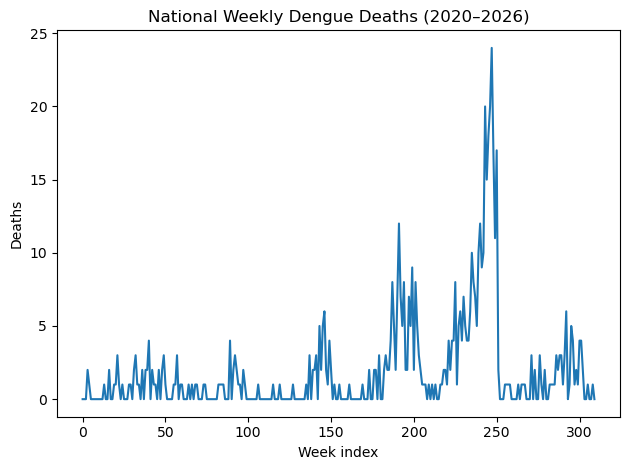

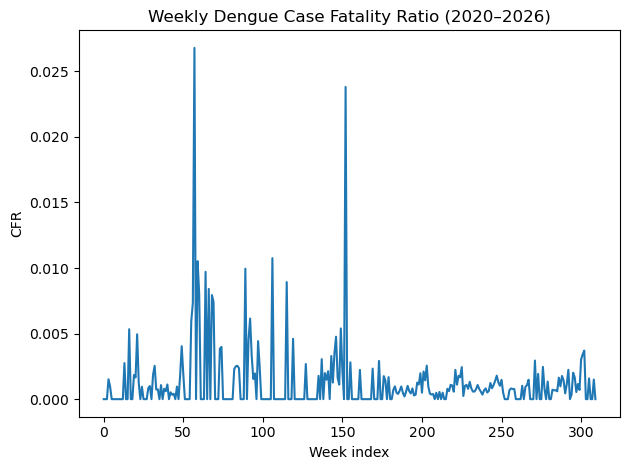

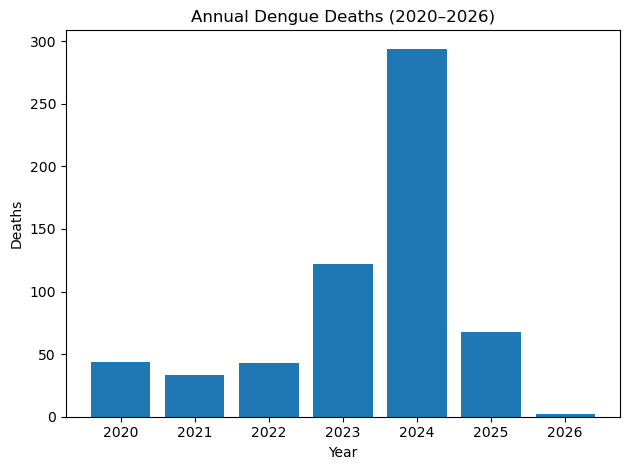

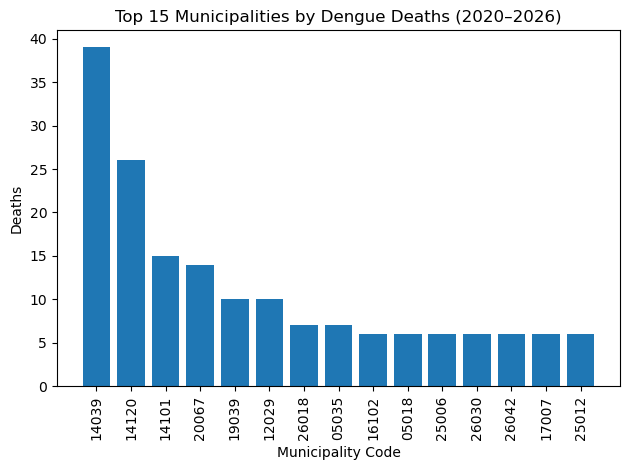

Total confirmed cases: 680360
Total deaths: 606
Overall CFR: 0.0008907049209242166

Annual mortality summary:
   iso_year  total_cases  deaths       cfr
0      2020        67526      44  0.000652
1      2021        14741      33  0.002239
2      2022        26145      43  0.001645
3      2023       168346     122  0.000725
4      2024       325495     294  0.000903
5      2025        74944      68  0.000907
6      2026         3163       2  0.000632


In [35]:



# Plot 1: Weekly deaths
plt.figure()
plt.plot(weekly["deaths"].values)
plt.title("National Weekly Dengue Deaths (2020–2026)")
plt.xlabel("Week index")
plt.ylabel("Deaths")
plt.tight_layout()
plt.show()

# Plot 2: Weekly case fatality ratio
plt.figure()
plt.plot(weekly["cfr"].fillna(0).values)
plt.title("Weekly Dengue Case Fatality Ratio (2020–2026)")
plt.xlabel("Week index")
plt.ylabel("CFR")
plt.tight_layout()
plt.show()

# Annual mortality summary
annual = conf.groupby("iso_year", as_index=False).agg(
    total_cases=("death_flag", "size"),
    deaths=("death_flag", "sum"),
)
annual["cfr"] = annual["deaths"] / annual["total_cases"]

plt.figure()
plt.bar(annual["iso_year"].astype(str), annual["deaths"])
plt.title("Annual Dengue Deaths (2020–2026)")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.tight_layout()
plt.show()

# Spatial mortality: top 15 municipalities by deaths
conf["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
conf["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
conf["muni_code"] = conf["ENTIDAD_RES"] + conf["MUNICIPIO_RES"]

muni_mort = conf.groupby("muni_code", as_index=False).agg(
    total_cases=("death_flag", "size"),
    deaths=("death_flag", "sum"),
)
muni_mort["cfr"] = muni_mort["deaths"] / muni_mort["total_cases"]

top_muni = muni_mort.sort_values("deaths", ascending=False).head(15)

plt.figure()
plt.bar(top_muni["muni_code"], top_muni["deaths"])
plt.xticks(rotation=90)
plt.title("Top 15 Municipalities by Dengue Deaths (2020–2026)")
plt.xlabel("Municipality Code")
plt.ylabel("Deaths")
plt.tight_layout()
plt.show()

print("Total confirmed cases:", conf.shape[0])
print("Total deaths:", conf["death_flag"].sum())
print("Overall CFR:", conf["death_flag"].mean())
print("\nAnnual mortality summary:")
print(annual)


In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load municipality shapefile
muni = gpd.read_file(r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp")

#print(muni.columns)

# 2. Build dengue confirmed dataset (already stacked)
full = pd.read_csv(r"C:\Users\Tosin\Downloads\BMC\full_dengue_2020_2026.csv")

# If you haven't saved it yet, we rebuild quickly
# Use your earlier stacked code

# 3. Create municipality code
full["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases = full.groupby("muni_code", as_index=False).size()
muni_cases = muni_cases.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged = muni.merge(muni_cases, on="muni_code", how="left")
muni_merged["total_cases"] = muni_merged["total_cases"].fillna(0)

plt.figure(figsize=(10,10))
muni_merged.plot(column="total_cases", legend=True)
plt.title("Cumulative Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()


NameError: name 'conf' is not defined

<Figure size 1000x1000 with 0 Axes>

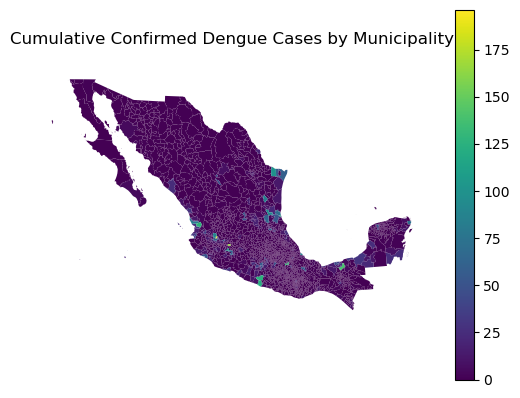

In [51]:
full_2020 = full[full['iso_year'] == 2020].copy()

# View the first few rows of the new 2020 dataset
full_2020["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full_2020["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full_2020["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases_2020 = full_2020.groupby("muni_code", as_index=False).size()
muni_cases_2020 = muni_cases_2020.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged_2020 = muni.merge(muni_cases_2020, on="muni_code", how="left")
muni_merged_2020["total_cases"] = muni_merged_2020["total_cases"].fillna(0)
plt.figure(figsize=(10,10))
muni_merged_2020.plot(column="total_cases", legend=True)
plt.title("Cumulative Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()

<Figure size 1000x1000 with 0 Axes>

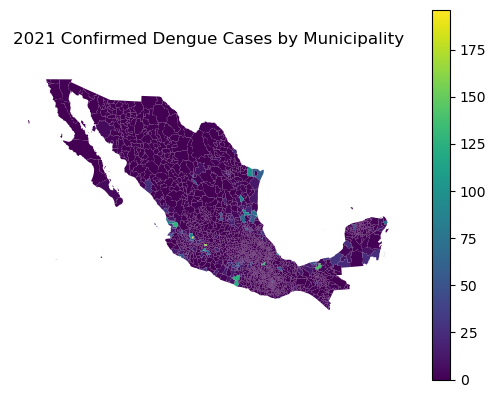

In [49]:
full_2021 = full[full['iso_year'] == 2021].copy()

# View the first few rows of the new 2020 dataset
full_2021["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full_2021["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full_2021["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases_2021 = full_2021.groupby("muni_code", as_index=False).size()
muni_cases_2021 = muni_cases_2021.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged_2021 = muni.merge(muni_cases_2021, on="muni_code", how="left")
muni_merged_2021["total_cases"] = muni_merged_2021["total_cases"].fillna(0)
plt.figure(figsize=(10,10))
muni_merged_2021.plot(column="total_cases", legend=True)
plt.title("2021 Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()

<Figure size 1000x1000 with 0 Axes>

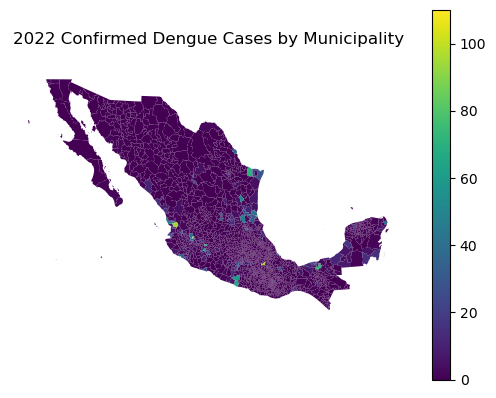

In [52]:
full_2022 = full[full['iso_year'] == 2022].copy()

# View the first few rows of the new 2020 dataset
full_2022["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full_2022["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full_2022["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases_2022 = full_2022.groupby("muni_code", as_index=False).size()
muni_cases_2022 = muni_cases_2022.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged_2022 = muni.merge(muni_cases_2022, on="muni_code", how="left")
muni_merged_2022["total_cases"] = muni_merged_2022["total_cases"].fillna(0)
plt.figure(figsize=(10,10))
muni_merged_2022.plot(column="total_cases", legend=True)
plt.title("2022 Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()

<Figure size 1000x1000 with 0 Axes>

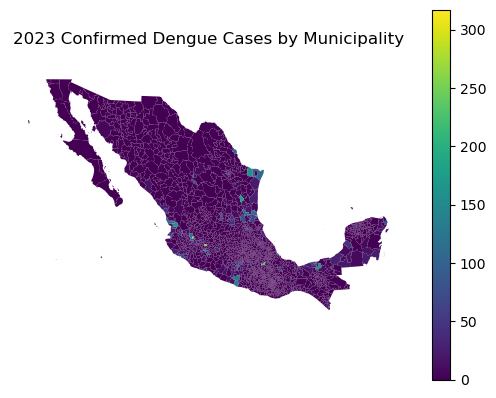

In [54]:
full_2023 = full[full['iso_year'] == 2023].copy()

# View the first few rows of the new 2020 dataset
full_2023["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full_2023["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full_2023["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases_2023 = full_2023.groupby("muni_code", as_index=False).size()
muni_cases_2023 = muni_cases_2023.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged_2023 = muni.merge(muni_cases_2023, on="muni_code", how="left")
muni_merged_2023["total_cases"] = muni_merged_2023["total_cases"].fillna(0)
plt.figure(figsize=(10,10))
muni_merged_2023.plot(column="total_cases", legend=True)
plt.title("2023 Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()

<Figure size 1000x1000 with 0 Axes>

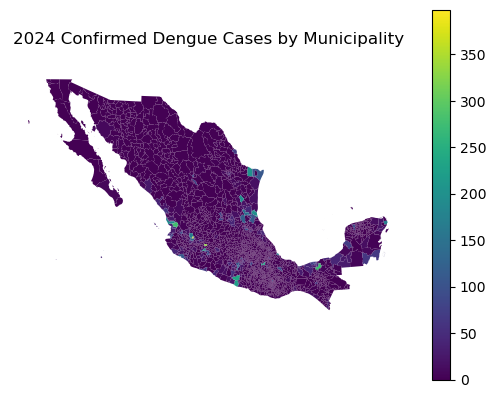

In [55]:
full_2024 = full[full['iso_year'] == 2024].copy()

# View the first few rows of the new 2020 dataset
full_2024["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full_2024["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full_2024["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases_2024 = full_2024.groupby("muni_code", as_index=False).size()
muni_cases_2024 = muni_cases_2024.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged_2024 = muni.merge(muni_cases_2024, on="muni_code", how="left")
muni_merged_2024["total_cases"] = muni_merged_2024["total_cases"].fillna(0)
plt.figure(figsize=(10,10))
muni_merged_2024.plot(column="total_cases", legend=True)
plt.title("2024 Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()

<Figure size 1000x1000 with 0 Axes>

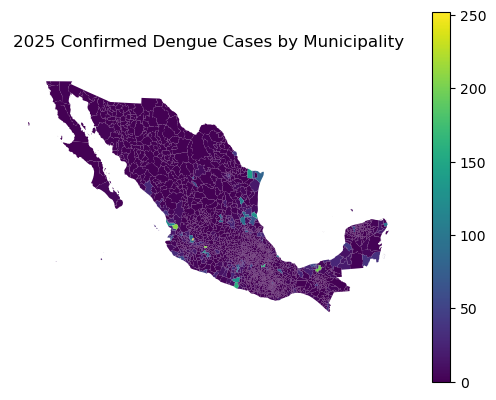

In [56]:
full_2025 = full[full['iso_year'] == 2025].copy()

# View the first few rows of the new 2020 dataset
full_2025["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full_2025["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full_2025["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases_2025 = full_2025.groupby("muni_code", as_index=False).size()
muni_cases_2025 = muni_cases_2025.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged_2025 = muni.merge(muni_cases_2025, on="muni_code", how="left")
muni_merged_2025["total_cases"] = muni_merged_2025["total_cases"].fillna(0)
plt.figure(figsize=(10,10))
muni_merged_2025.plot(column="total_cases", legend=True)
plt.title("2025 Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()

<Figure size 1000x1000 with 0 Axes>

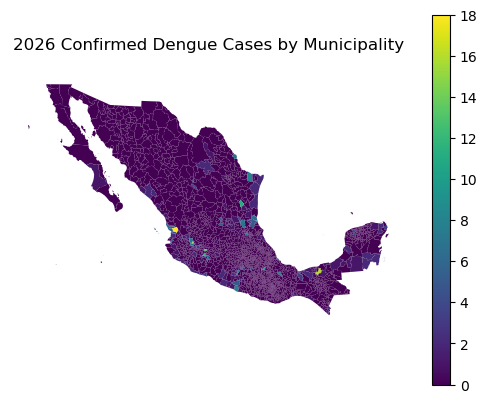

In [57]:
full_2026 = full[full['iso_year'] == 2026].copy()

# View the first few rows of the new 2020 dataset
full_2026["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full_2026["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full_2026["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases_2026 = full_2026.groupby("muni_code", as_index=False).size()
muni_cases_2026 = muni_cases_2026.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged_2026 = muni.merge(muni_cases_2026, on="muni_code", how="left")
muni_merged_2026["total_cases"] = muni_merged_2026["total_cases"].fillna(0)
plt.figure(figsize=(10,10))
muni_merged_2026.plot(column="total_cases", legend=True)
plt.title("2026 Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()

Index(['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'NOMGEO', 'geometry'], dtype='object')


<Figure size 1000x1000 with 0 Axes>

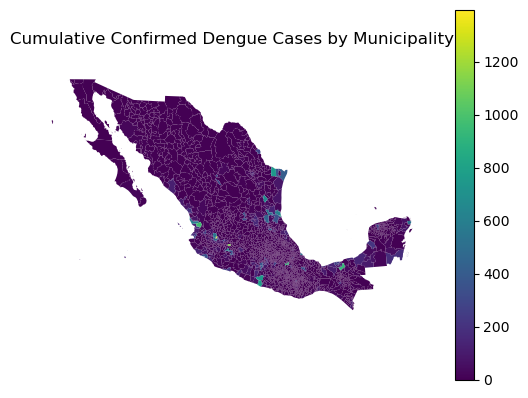

In [58]:

muni = gpd.read_file(r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp")

print(muni.columns)

# 2. Build dengue confirmed dataset (already stacked)
full = pd.read_csv(r"C:\Users\Tosin\Downloads\BMC\full_dengue_2020_2026.csv")

# If you haven't saved it yet, we rebuild quickly
# Use your earlier stacked code

# 3. Create municipality code
full["ENTIDAD_RES"] = conf["ENTIDAD_RES"].astype(int).astype(str).str.zfill(2)
full["MUNICIPIO_RES"] = conf["MUNICIPIO_RES"].astype(int).astype(str).str.zfill(3)
full["muni_code"] = conf["ENTIDAD_RES"] + full["MUNICIPIO_RES"]

# 4. Aggregate cumulative confirmed cases
muni_cases = full.groupby("muni_code", as_index=False).size()
muni_cases = muni_cases.rename(columns={"size": "total_cases"})

# 5. Identify municipality ID in shapefile
# INEGI typically uses CVEGEO
muni["muni_code"] = muni["CVEGEO"].astype(str)

# 6. Merge
muni_merged = muni.merge(muni_cases, on="muni_code", how="left")
muni_merged["total_cases"] = muni_merged["total_cases"].fillna(0)

plt.figure(figsize=(10,10))
muni_merged.plot(column="total_cases", legend=True)
plt.title("Cumulative Confirmed Dengue Cases by Municipality")
plt.axis("off")
plt.show()


### Annual cumulative confirmed dengue cases exhibited pronounced spatial heterogeneity across Mexican municipalities between 2020 and 2025.

Across all years, the highest case burdens were consistently concentrated in municipalities along the Gulf Coast, Pacific Coast, and southern tropical regions. Notably, municipalities such as Veracruz (Veracruz), Coatzacoalcos (Veracruz), Villahermosa (Centro, Tabasco), and Tuxtla Gutiérrez (Chiapas) repeatedly appeared among the highest-burden locations. Elevated counts were also observed in Acapulco de Juárez (Guerrero) and Tapachula (Chiapas), particularly during high-transmission years.

In the Yucatán Peninsula, municipalities including Mérida (Yucatán) and Benito Juárez (Cancún, Quintana Roo) demonstrated sustained transmission across multiple years, with visible intensification during 2023 and 2024.

In contrast, northern municipalities—particularly in Chihuahua, Coahuila, and Durango—consistently exhibited very low case counts, reflecting the well-documented latitudinal gradient in dengue suitability


he 2024 map shows a marked nationwide intensification relative to prior years. Municipalities in:

Veracruz (state)

Tabasco

Guerrero

Oaxaca

Chiapas

displayed substantial increases in case counts compared with 2020–2023. Urban municipalities such as Villahermosa, Acapulco, and municipalities in the Veracruz coastal corridor showed particularly strong amplification.

This spatial pattern suggests a broad-scale climatic or ecological driver rather than a localized outbreak.

The cumulative 2020–2025 map highlights persistent high-burden corridors. The most prominent cluster extends from:

Southern Veracruz
through

Tabasco
into

Chiapas

with additional concentration along the Pacific coastal belt in Guerrero and Oaxaca.

These municipalities represent sustained transmission zones over multiple years rather than isolated epidemic spikes.

### Figure Title: “Cumulative confirmed dengue cases by municipality, Mexico, 2020–2025. Values represent the total number of laboratory-confirmed cases aggregated across all weeks during the study period. Maps illustrate spatial heterogeneity in burden and do not adjust for population size

## Spatial Distribution of Cumulative Dengue Burden, 2020–2025

The cumulative 2020–2025 map demonstrates pronounced geographic heterogeneity in confirmed dengue burden across Mexican municipalities.

High cumulative case counts are concentrated predominantly in the southern and southeastern regions of Mexico, particularly along:

The Gulf Coast corridor

The Pacific coastal belt in the southwest

The Yucatán Peninsula

A continuous high-burden band is visible extending from the southern Gulf Coast through the Isthmus region into southeastern Mexico. Municipalities in these areas exhibit persistently elevated cumulative case counts relative to the national distribution.

In contrast, municipalities in the northern and north-central regions display consistently low cumulative case counts over the study period. This north–south gradient aligns with known ecological suitability patterns for dengue transmission, including temperature and humidity constraints on vector survival.

The cumulative surface also reveals that transmission burden is not uniformly distributed within high-incidence states. Instead, clusters of municipalities exhibit markedly elevated counts relative to neighboring areas, suggesting localized ecological or urban drivers of sustained transmission.

Overall, the cumulative map indicates:

Persistent transmission foci in tropical and subtropical regions

A clear latitudinal gradient in burden

Geographic clustering rather than homogeneous nationwide spread

Warmer, humid, lower-elevation regions provide favorable conditions for Aedes vector persistence.

Coastal and southern regions exhibit environmental conditions conducive to year-round transmission.

Northern municipalities, characterized by cooler and drier climates, remain comparatively unsuitable for sustained transmission.

However, because these maps reflect raw case counts, they represent disease burden rather than population-adjusted risk. Differences in municipality population size may partially contribute to observed intensity patterns.

In [ ]:
#  I. DESCRIPTIVE SPATIOTEMPORAL PATTERNS

# Annual Burden Maps (2020–2025): To show interannual variation and persistent high-burden regions
